# 04 — Split temporel, backtesting & features (anti-leakage)

## Objectifs
1) Définir un split temporel strict (train/val/test) et le figer pour tout le projet.
2) Mettre en place une procédure de backtesting temporel (folds expanding/rolling) pour évaluer sans fuite.
3) Évaluer des baselines en walk-forward et construire les premières features calendaires comme références.


In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path("..").resolve()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.backtesting import (
    make_folds,
    build_series_by_station,
    evaluate_baselines_walkforward,)
from src.features import build_features_v0

# Paths principaux 
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "base1_clean.parquet"
FIG_DIR   = PROJECT_ROOT / "reports" / "figures" / "04_split_backtesting"   
CONFIG = PROJECT_ROOT  / "Configs"
# Artifacts Notebook 04 
ART_04     = PROJECT_ROOT / "artifacts" / "04_backtesting"
ART_04_TBL = ART_04 / "tables"
ART_04_MET = ART_04 / "metrics"
ART_04_PRD = ART_04 / "predictions"
ART_04_PLT = ART_04 / "plots"
ART_04_SUM = ART_04 / "summary"

for d in [FIG_DIR, ART_04, ART_04_TBL, ART_04_MET, ART_04_PRD, ART_04_PLT, ART_04_SUM]:
    d.mkdir(parents=True, exist_ok=True)

# --- Config projet ---
SEED = 42
VAL_START  = pd.Timestamp("2018-01-01")
TEST_START = pd.Timestamp("2018-07-01")

# horizons en pas de 2h (1=2h, 12=1j, 84=7j)
HORIZONS = {"h2": 1, "d1": 12, "w1": 84}

np.random.seed(SEED)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_PATH:", DATA_PATH)
print("FIG_DIR:", FIG_DIR)
print("ART_04_SUM:", ART_04_SUM)
print("ART_04_TBL:", ART_04_TBL)

PROJECT_ROOT: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle
DATA_PATH: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\data\processed\base1_clean.parquet
FIG_DIR: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\reports\figures\04_split_backtesting
ART_04_SUM: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\04_backtesting\summary
ART_04_TBL: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\04_backtesting\tables


In [3]:
# ---------- CONFIG ----------
CONFIG_PATH = PROJECT_ROOT / CONFIG / "ts_config.json"
CONFIG_PATH.parent.mkdir(parents=True, exist_ok=True)  # sécurité

DEFAULT_CFG = {
    "seed": int(SEED),
    "val_start": str(VAL_START),
    "test_start": str(TEST_START),
    "horizons_steps_2h": {k: int(v) for k, v in HORIZONS.items()},
    "backtesting": {
        "step_days": 30,
        "eval_window_days": 30,
        "min_train_days": 365,
        "rolling_window_days": 730,
    },
}

if not CONFIG_PATH.exists():
    with open(CONFIG_PATH, "w", encoding="utf-8") as f:
        json.dump(DEFAULT_CFG, f, indent=2, ensure_ascii=False)
    print("Created:", CONFIG_PATH)

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    CFG = json.load(f)

SEED = int(CFG["seed"])
VAL_START = pd.Timestamp(CFG["val_start"])
TEST_START = pd.Timestamp(CFG["test_start"])
HORIZONS = {k: int(v) for k, v in CFG["horizons_steps_2h"].items()}

print("Loaded config:", CONFIG_PATH)
print("VAL_START:", VAL_START, "| TEST_START:", TEST_START, "| HORIZONS:", HORIZONS)

Loaded config: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\Configs\ts_config.json
VAL_START: 2018-01-01 00:00:00 | TEST_START: 2018-07-01 00:00:00 | HORIZONS: {'h2': 1, 'd1': 12, 'w1': 84}


In [3]:
# ---------- MLFLOW (rrobuste) ----------
USE_MLFLOW = True

if USE_MLFLOW:
    import mlflow
    from mlflow.tracking import MlflowClient
    from datetime import datetime

    BASE_EXP_NAME = "river_temp_ts"   
    MLFLOW_DIR = PROJECT_ROOT / "mlflow"
    MLFLOW_DIR.mkdir(parents=True, exist_ok=True)

    # DB metadata
    DB_PATH = (MLFLOW_DIR / "mlflow.db").resolve()

    MLRUN_DIR = (MLFLOW_DIR / "mlrun").resolve()
    MLRUN_DIR.mkdir(parents=True, exist_ok=True)

    # Config tracking
    mlflow.set_tracking_uri(f"sqlite:///{DB_PATH.as_posix()}")
    artifact_root = MLRUN_DIR.as_uri()   

    client = MlflowClient()
    exp = client.get_experiment_by_name(BASE_EXP_NAME)

    # Fonction pour créer un nouveau nom si besoin
    def new_exp_name():
        return f"{BASE_EXP_NAME}_{datetime.now():%Y%m%d_%H%M%S}"

    if exp is None:
        # Pas d'expérience -> on crée
        exp_id = client.create_experiment(BASE_EXP_NAME, artifact_location=artifact_root)
        exp = client.get_experiment(exp_id)

    else:
        bad_state = (exp.lifecycle_stage != "active")
        bad_artifacts = (exp.artifact_location != artifact_root)

        if bad_state or bad_artifacts:
            exp_name = new_exp_name()
            exp_id = client.create_experiment(exp_name, artifact_location=artifact_root)
            exp = client.get_experiment(exp_id)

    # Active l'expérience trouvée/créée
    mlflow.set_experiment(experiment_id=exp.experiment_id)

    print("MLflow tracking URI  :", mlflow.get_tracking_uri())
    print("MLflow experiment    :", exp.name)
    print("MLflow experiment ID :", exp.experiment_id)
    print("MLflow lifecycle     :", exp.lifecycle_stage)
    print("MLflow artifact root :", exp.artifact_location)

MLflow tracking URI  : sqlite:///C:/Users/El-fahad COMBO/Desktop/Serie_temporelle/Mlflow/mlflow.db
MLflow experiment    : river_temp_ts_20260225_171147
MLflow experiment ID : 18
MLflow lifecycle     : active
MLflow artifact root : file:///C:/Users/El-fahad%20COMBO/Desktop/Serie_temporelle/Mlflow/mlrun


## 1. Chargement + split temporel + contrôles

**Objectif.** Charger le dataset `processed`, définir un split temporel **a priori** (train/val/test) et vérifier les invariants de base (timestamps valides, tri temporel par station, absence de doublons).

**Split retenu.**
- **Train** : `ts < 2018-01-01`
- **Validation** : `2018-01-01 ≤ ts < 2018-07-01`
- **Test** : `ts ≥ 2018-07-01`

**Sorties attendues.**
- Un tableau de contrôle `split_check` (min/max/count par split).
- Un résumé exporté dans `artifacts/summary/` (`split_summary.json` + `.csv`) et une table `artifacts/tables/split_check.csv`.

In [4]:
import json, numpy as np, pandas as pd

df = pd.read_parquet(DATA_PATH).sort_values(["id_sonde","ts"]).reset_index(drop=True)
assert pd.api.types.is_datetime64_any_dtype(df["ts"])
assert df.duplicated(["id_sonde","ts"]).sum() == 0
assert df.groupby("id_sonde")["ts"].apply(lambda s: s.is_monotonic_increasing).all()

df["split"] = np.select([df["ts"] < VAL_START, df["ts"] < TEST_START], ["train","val"], default="test")

split_check = df.groupby("split")["ts"].agg(["min","max","count"]).sort_index()
display(split_check)

summary = {
    "n_rows": int(len(df)),
    "n_cols": int(df.shape[1]),
    "n_stations": int(df["id_sonde"].nunique()),
    "stations": sorted(df["id_sonde"].unique()),
    "min_ts": str(df["ts"].min()),
    "max_ts": str(df["ts"].max()),
    "val_start": str(VAL_START),
    "test_start": str(TEST_START),
    "split_counts": df["split"].value_counts().to_dict(), }

def _json_default(o):
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return float(o)
    if isinstance(o, (pd.Timestamp,)): return o.isoformat()
    return str(o)

with open(ART_04_SUM/"split_summary.json","w",encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False, default=_json_default)

pd.DataFrame([summary]).to_csv(ART_04_SUM/"split_summary.csv", index=False)
split_check.to_csv(ART_04_TBL/"split_check.csv")

print("Saved:", ART_04_SUM/"split_summary.json")
print("Saved:", ART_04_SUM/"split_summary.csv")
print("Saved:", ART_04_TBL/"split_check.csv")

,min,max,count
split,,,
test,2018-07-01 00:00:00,2018-10-05 08:00:00,8099
train,2013-05-29 14:00:00,2017-12-31 22:00:00,140903
val,2018-01-01 00:00:00,2018-06-30 22:00:00,15204


Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\04_backtesting\summary\split_summary.json
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\04_backtesting\summary\split_summary.csv
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\04_backtesting\tables\split_check.csv


## 2 — QC split par station 

Objectif : valider **par station** que le split train/val/test est exploitable :
- fréquence dominante **2h** (deltas temporels),
- détection de **gaps** (> 2h),
- taux de **valeurs manquantes** sur la cible,
- visualisation de la **couverture temporelle** (min ->max) par station et par split.

Avant de faire du backtesting et des baselines, on doit être sûr que les séries ne sont pas "cassées" sur une station
(gaps longs, fréquence instable, segments manquants), sinon les métriques seront biaisées.

,split,id_sonde,n_rows,ts_min,ts_max,pct_delta_2h,n_gaps_gt_2h,max_gap_hours,n_missing_target,missing_target_rate
0,test,817,1157,2018-07-01 00:00:00,2018-10-05 08:00:00,1.0,0,2.0,0,0.0
1,test,818,1157,2018-07-01 00:00:00,2018-10-05 08:00:00,1.0,0,2.0,0,0.0
2,test,819,1157,2018-07-01 00:00:00,2018-10-05 08:00:00,1.0,0,2.0,0,0.0
3,test,825,1157,2018-07-01 00:00:00,2018-10-05 08:00:00,1.0,0,2.0,0,0.0
4,test,827,1157,2018-07-01 00:00:00,2018-10-05 08:00:00,1.0,0,2.0,0,0.0
5,test,828,1157,2018-07-01 00:00:00,2018-10-05 08:00:00,1.0,0,2.0,0,0.0
6,test,830,1157,2018-07-01 00:00:00,2018-10-05 08:00:00,1.0,0,2.0,0,0.0
7,train,817,20129,2013-05-29 14:00:00,2017-12-31 22:00:00,1.0,0,2.0,0,0.0
8,train,818,20129,2013-05-29 14:00:00,2017-12-31 22:00:00,1.0,0,2.0,0,0.0
9,train,819,20129,2013-05-29 14:00:00,2017-12-31 22:00:00,1.0,0,2.0,0,0.0


Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\04_backtesting\tables\qc_station_split.csv


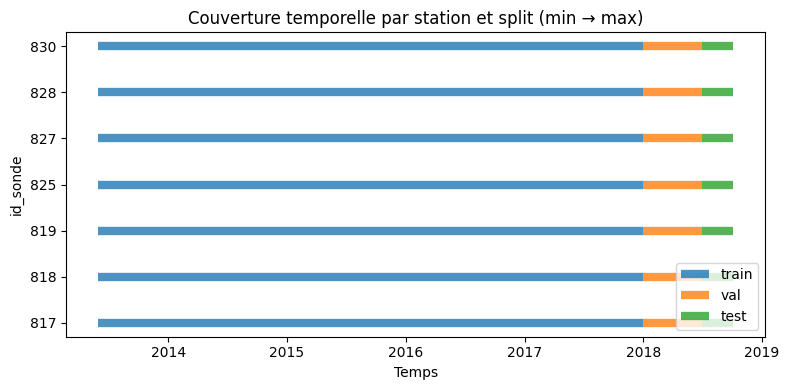

Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\reports\figures\04_split_backtesting\coverage_station_split.png
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\04_backtesting\plots\coverage_station_split.png
Bad rows: 0


,split,id_sonde,n_rows,ts_min,ts_max,pct_delta_2h,n_gaps_gt_2h,max_gap_hours,n_missing_target,missing_target_rate


In [5]:
for c in ["id_sonde", "ts", "split"]:
    assert c in df.columns, f"Colonne manquante: {c}"
assert df["ts"].isna().sum() == 0, "NaT détectés dans ts"
assert df.duplicated(["id_sonde", "ts"]).sum() == 0, "Doublons (id_sonde, ts) détectés"
assert df.groupby("id_sonde")["ts"].apply(lambda s: s.is_monotonic_increasing).all(), "ts pas monotone dans au moins une station"

TARGET = "temp_water_c"
assert TARGET in df.columns, f"Colonne cible manquante: {TARGET}"

EXPECTED = pd.Timedelta(hours=2)

def qc_group(g: pd.DataFrame):
    ts = g["ts"]
    d = ts.diff().dropna()
    pct_2h = float((d == EXPECTED).mean()) if len(d) else np.nan
    n_gaps = int((d > EXPECTED).sum()) if len(d) else 0
    max_gap_h = float(d.max().total_seconds()/3600) if len(d) else np.nan
    return pd.Series({
        "n_rows": int(len(g)),
        "ts_min": ts.min(),
        "ts_max": ts.max(),
        "pct_delta_2h": pct_2h,
        "n_gaps_gt_2h": n_gaps,
        "max_gap_hours": max_gap_h,
        "n_missing_target": int(g[TARGET].isna().sum()),
        "missing_target_rate": float(g[TARGET].isna().mean()),})

qc_station_split = (
    df.groupby(["split", "id_sonde"], sort=True)[["ts", TARGET]]
      .apply(qc_group)
      .reset_index()
      .sort_values(["split", "id_sonde"])
      .reset_index(drop=True))

display(qc_station_split)

# export table
qc_path = ART_04_TBL / "qc_station_split.csv"
qc_station_split.to_csv(qc_path, index=False)
print("Saved:", qc_path)

#  plot couverture temporelle par station et split
cov = qc_station_split[["split", "id_sonde", "ts_min", "ts_max"]].copy()
cov["split"] = pd.Categorical(cov["split"], ["train", "val", "test"], ordered=True)
cov = cov.sort_values(["id_sonde", "split"])

fig, ax = plt.subplots(figsize=(8, 4))
stations = cov["id_sonde"].unique().tolist()
ypos = {sid: i for i, sid in enumerate(stations)}

split_colors = {"train": "C0", "val": "C1", "test": "C2"}


for _, r in cov.iterrows():
    ax.hlines(
        y=ypos[r["id_sonde"]],
        xmin=r["ts_min"],
        xmax=r["ts_max"],
        linewidth=6,
        alpha=0.8,
        color=split_colors[r["split"]],
        label=str(r["split"]))

ax.set_yticks(list(ypos.values()))
ax.set_yticklabels([str(s) for s in stations])
ax.set_title("Couverture temporelle par station et split (min → max)")
ax.set_xlabel("Temps")
ax.set_ylabel("id_sonde")

handles, labels = ax.get_legend_handles_labels()
uniq = {}
for h, lab in zip(handles, labels):
    uniq.setdefault(lab, h)
ax.legend(uniq.values(), uniq.keys(), loc="lower right")

fig.tight_layout()
fig_path = FIG_DIR / "coverage_station_split.png"
fig_path2 = ART_04_PLT / "coverage_station_split.png"
fig.savefig(fig_path, dpi=160)
fig.savefig(fig_path2, dpi=160)
plt.show()
print("Saved:", fig_path)
print("Saved:", fig_path2)

# stations/splits
bad = qc_station_split[(qc_station_split["pct_delta_2h"] < 0.99) | (qc_station_split["n_gaps_gt_2h"] > 0)]
print("Bad rows:", len(bad))
display(bad)

### QC du split (par station × split)

Le split train/val/test est **aligné et exploitable** sur l’ensemble des 7 stations.

- **Régularité temporelle** : 100% des deltas sont égaux à 2h (`pct_delta_2h = 1.0`), aucun écart de fréquence détecté.
- **Gaps** : aucun gap > 2h (`n_gaps_gt_2h = 0`), donc pas de rupture de série.
- **Cible (température eau)** : aucune valeur manquante (`n_missing_target = 0`).
- **Couverture temporelle** : bornes identiques entre stations et splits, confirmées par la figure `coverage_station_split.png`.

Taille des splits (par station) : train = 20129, val = 2172, test = 1157 observations.
Conclusion : les séries sont **régulières et complètes**, prêtes pour backtesting et baselines.

### 2.1 vérif NA par split 

In [6]:
na_by_split = (
    df.isna()
      .groupby(df["split"])
      .mean()
      .mul(100)
      .stack()
      .rename("pct_missing")
      .reset_index()
      .rename(columns={"level_1": "variable"}))

top_na = (na_by_split[na_by_split["pct_missing"] > 0]
          .sort_values(["split", "pct_missing"], ascending=[True, False]))

display(top_na.head(30))

print("NA temp_water_c par split:")
display(df.groupby("split")["temp_water_c"].apply(lambda s: int(s.isna().sum())))

,split,variable,pct_missing
9,test,discharge_q,2.345969
11,test,discharge_q_mmj,2.345969
14,test,temp_tg_ref_eobs,2.345969
33,train,discharge_q,0.536539
35,train,discharge_q_mmj,0.536539
38,train,temp_tg_ref_eobs,0.400275
34,train,discharge_q_qjm,0.353435
45,train,dtemp_2h,0.004968


NA temp_water_c par split:


split
test     0
train    0
val      0
Name: temp_water_c, dtype: int64

### Audit des valeurs manquantes (par split)

- La cible **température d’eau** `temp_water_c` ne contient **aucune valeur manquante** sur les trois splits (train/val/test).
- Des valeurs manquantes subsistent sur certaines variables exogènes (principalement `discharge_q`, `discharge_q_mmj`, `temp_tg_ref_eobs` et `discharge_q_qjm`), avec un taux plus élevé sur la période test (~2.35%).
- Implication méthodologique (anti-leakage) : toute imputation des exogènes devra être **causale** et réalisée **dans chaque fold de backtesting** (fit sur train uniquement), en conservant des indicateurs de manque si nécessaire.

## 3 — Génération des folds de backtesting (expanding / rolling)

Objectif : construire des folds temporels stricts (anti-leakage) pour l’évaluation des baselines
et des futurs modèles (Notebook 06).

- `expanding` : la fenêtre d’entraînement grandit dans le temps.
- `rolling` : la fenêtre d’entraînement glisse avec une taille fixe.
- Les fenêtres d’évaluation sont fixes (30 jours).

In [7]:
EXPECTED = pd.Timedelta(hours=2)

BT_END = df.loc[df["split"] == "val", "ts"].max()   # on backteste sur train+val
BT_START = df["ts"].min()
ts_index = pd.Index(sorted(df["ts"].unique()))

folds_exp = make_folds(
    ts_index,
    BT_START,
    BT_END,
    mode="expanding",
    step=pd.Timedelta(days=30),
    eval_window=pd.Timedelta(days=30),
    min_train=pd.Timedelta(days=365),
    rolling_window=pd.Timedelta(days=730),  # ignoré ici
    expected=EXPECTED,
)

folds_roll = make_folds(
    ts_index,
    BT_START,
    BT_END,
    mode="rolling",
    step=pd.Timedelta(days=30),
    eval_window=pd.Timedelta(days=30),
    min_train=pd.Timedelta(days=365),
    rolling_window=pd.Timedelta(days=730),
    expected=EXPECTED,
)

display(folds_exp.head(3))
display(folds_roll.head(3))

folds_exp.to_csv(ART_04_TBL / "backtest_folds_expanding.csv", index=False)
folds_roll.to_csv(ART_04_TBL / "backtest_folds_rolling.csv", index=False)
print("Saved:", ART_04_TBL / "backtest_folds_expanding.csv")
print("Saved:", ART_04_TBL / "backtest_folds_rolling.csv")

,fold_id,mode,train_start,train_end,eval_start,eval_end
0,1,expanding,2013-05-29 14:00:00,2014-05-29 14:00:00,2014-05-29 16:00:00,2014-06-28 14:00:00
1,2,expanding,2013-05-29 14:00:00,2014-06-28 14:00:00,2014-06-28 16:00:00,2014-07-28 14:00:00
2,3,expanding,2013-05-29 14:00:00,2014-07-28 14:00:00,2014-07-28 16:00:00,2014-08-27 14:00:00


,fold_id,mode,train_start,train_end,eval_start,eval_end
0,1,rolling,2013-05-29 14:00:00,2014-05-29 14:00:00,2014-05-29 16:00:00,2014-06-28 14:00:00
1,2,rolling,2013-05-29 14:00:00,2014-06-28 14:00:00,2014-06-28 16:00:00,2014-07-28 14:00:00
2,3,rolling,2013-05-29 14:00:00,2014-07-28 14:00:00,2014-07-28 16:00:00,2014-08-27 14:00:00


Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\04_backtesting\tables\backtest_folds_expanding.csv
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\04_backtesting\tables\backtest_folds_rolling.csv


### Interprétation

Les folds sont cohérents avec le protocole :

- `eval_start = train_end + 2h`  (séparation stricte, pas de fuite)
- fenêtre d’évaluation ≈ **30 jours** 
- pas entre folds = **30 jours** 

Les premiers folds `expanding` et `rolling` sont identiques, ce qui est normal ici (fenêtre rolling large et début de backtesting).

## 4 — Baselines & premières métriques (walk-forward sur les folds + MLflow)

Objectif : établir des modèles de référence (naïf / saisonnier) et calculer des métriques (MAE, RMSE, sMAPE)
sur les folds de backtesting (expanding et rolling), afin d’obtenir un niveau de base avant les modèles.

évaluation :
- Les baselines sont évaluées en **walk-forward** sur **tous les timestamps** de chaque fenêtre d’évaluation (`eval_start => eval_end`).
- Pour chaque horizon (2h, 1j, 1 semaine), on calcule une prédiction causale à chaque timestamp cible.
- Cela permet une comparaison plus robuste et directement comparable aux futurs modèles du notebook 06.

Baselines :
- **Naïf (h-step)** : prédire `y(t)` par la dernière valeur disponible à l’horizon considéré, soit `y(t-h)`.
- **Saisonnier naïf** : prédire `y(t)` par une valeur passée avec période fixe :
  - période 24h (m=12 pas de 2h) pour horizons courts,
  - période 7 jours (m=84 pas de 2h) pour horizon 1 semaine.

Tracking :
- Logging MLflow des paramètres (split, horizons, backtesting) + métriques + artefacts (CSV + figure).

### 4.1 — Évaluation des baselines (walk-forward)

On évalue les baselines (naïf / saisonnier) sur tous les timestamps de chaque fenêtre d’évaluation
des folds `expanding` et `rolling`.

Sorties :
- `preds_baseline` : toutes les prédictions (audit détaillé)
- `metrics_global` : métriques agrégées par mode / modèle / horizon
- `metrics_station` : métriques agrégées par station

In [8]:
TARGET = "temp_water_c"
EXPECTED = pd.Timedelta(hours=2)

# séries par station
series_by_station = build_series_by_station(
    df,
    id_col="id_sonde",
    ts_col="ts",
    target_col=TARGET,)

# saisonnalité (en pas de 2h)
SEASON_BY_H = {"h2": 12, "d1": 12, "w1": 84}

# expanding
preds_exp, global_exp, station_exp = evaluate_baselines_walkforward(
    folds_exp,
    series_by_station,
    horizons=HORIZONS,      
    season_by_h=SEASON_BY_H,
    expected=EXPECTED,
    mode_name="expanding",)

# rolling
preds_roll, global_roll, station_roll = evaluate_baselines_walkforward(
    folds_roll,
    series_by_station,
    horizons=HORIZONS,
    season_by_h=SEASON_BY_H,
    expected=EXPECTED,
    mode_name="rolling",)

# concat global
preds_baseline = pd.concat([preds_exp, preds_roll], ignore_index=True)
metrics_global = pd.concat([global_exp, global_roll], ignore_index=True)
metrics_station = pd.concat([station_exp, station_roll], ignore_index=True)

display(metrics_global)

# exports
preds_path = ART_04_PRD / "baseline_predictions_walkforward.csv"
mglob_path = ART_04_MET / "baseline_metrics_global.csv"
msta_path  = ART_04_MET / "baseline_metrics_by_station.csv"

preds_baseline.to_csv(preds_path, index=False)
metrics_global.to_csv(mglob_path, index=False)
metrics_station.to_csv(msta_path, index=False)

print("Saved:", preds_path)
print("Saved:", mglob_path)
print("Saved:", msta_path)

,mode,model,horizon,mae,rmse,smape,n_preds
0,expanding,naive,d1,0.539137,0.697591,5.453173,123480
1,expanding,seasonal_m12,d1,0.539137,0.697591,5.453173,123480
2,expanding,naive,h2,0.155547,0.223778,1.371949,123480
3,expanding,seasonal_m12,h2,0.539137,0.697591,5.453173,123480
4,expanding,naive,w1,1.469651,1.867238,14.944185,123480
5,expanding,seasonal_m84,w1,1.469651,1.867238,14.944185,123480
6,rolling,naive,d1,0.539137,0.697591,5.453173,123480
7,rolling,seasonal_m12,d1,0.539137,0.697591,5.453173,123480
8,rolling,naive,h2,0.155547,0.223778,1.371949,123480
9,rolling,seasonal_m12,h2,0.539137,0.697591,5.453173,123480


Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\04_backtesting\predictions\baseline_predictions_walkforward.csv
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\04_backtesting\metrics\baseline_metrics_global.csv
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\04_backtesting\metrics\baseline_metrics_by_station.csv


### Interprétation

Les résultats sont cohérents :

- l’erreur augmente avec l’horizon (**h2 < d1 < w1**)
- la baseline **naïve à 2h** est la meilleure (MAE la plus faible)
- `naive(d1)` = `seasonal_m12` et `naive(w1)` = `seasonal_m84` (même décalage, donc mêmes prédictions)

Les métriques sont identiques entre `expanding` et `rolling`, ce qui est normal ici :
- baselines sans apprentissage (pas de fit)
- folds très proches sur cette période

### 4.2 — Visualisation des performances baseline (expanding vs rolling)

On trace la MAE des baselines par horizon pour comparer les deux stratégies de backtesting :
- expanding
- rolling

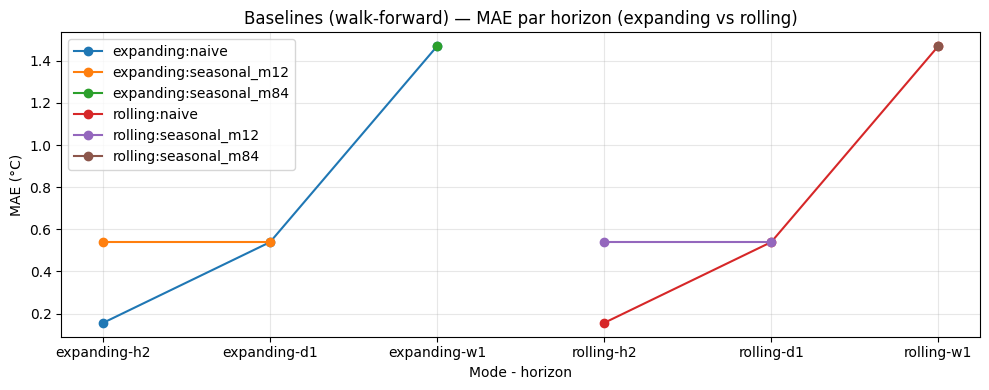

Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\reports\figures\04_split_backtesting\baseline_mae_by_horizon.png
Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\artifacts\04_backtesting\plots\baseline_mae_by_horizon.png


In [9]:
h_order = ["h2", "d1", "w1"]

fig, ax = plt.subplots(figsize=(10, 4))

for mode_name in ["expanding", "rolling"]:
    sub_mode = metrics_global[metrics_global["mode"] == mode_name].copy()

    for model_name in sorted(sub_mode["model"].unique()):
        sub = sub_mode[sub_mode["model"] == model_name].copy()
        sub["horizon"] = pd.Categorical(sub["horizon"], categories=h_order, ordered=True)
        sub = sub.sort_values("horizon")

        x = [f"{mode_name}-{h}" for h in sub["horizon"].astype(str)]
        ax.plot(x, sub["mae"].values, marker="o", label=f"{mode_name}:{model_name}")

ax.set_title("Baselines (walk-forward) — MAE par horizon (expanding vs rolling)")
ax.set_xlabel("Mode - horizon")
ax.set_ylabel("MAE (°C)")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()

fig_path = FIG_DIR / "baseline_mae_by_horizon.png"
FIG_PATH2 = ART_04_PLT / "baseline_mae_by_horizon.png"
fig.savefig(fig_path, dpi=160, bbox_inches="tight")
fig.savefig(FIG_PATH2, dpi=160, bbox_inches="tight")
plt.show()

print("Saved:", fig_path)
print("Saved:", FIG_PATH2)

### Interprétation de la figure

La figure confirme le tableau :

- **MAE** augmente avec l’horizon (`h2`, `d1`, `w1`)
- `expanding` et `rolling` se superposent (performances identiques)
- la baseline naïve est très forte à court terme (2h)

Cette figure sert de **benchmark visuel** pour comparer les modèles du Notebook 06.

### 4.3 — Tracking MLflow (paramètres, métriques, artefacts)

On enregistre dans MLflow :
- paramètres (split, horizons, saisonnalité, mode)
- métriques globales (MAE / RMSE / sMAPE)
- artefacts (CSV des métriques + figure)

In [10]:
# --- MLflow logging ---
if USE_MLFLOW:
    import mlflow

    for mode_name in ["expanding", "rolling"]:
        run_name = f"04_baselines_walkforward_{mode_name}"

        with mlflow.start_run(run_name=run_name):
            # Params
            mlflow.log_param("seed", int(SEED))
            mlflow.log_param("val_start", str(VAL_START))
            mlflow.log_param("test_start", str(TEST_START))
            mlflow.log_param("mode", mode_name)
            mlflow.log_param("eval_protocol", "walkforward_all_eval_timestamps")
            mlflow.log_param("horizons", str(HORIZONS))
            mlflow.log_param("season_by_horizon", str(SEASON_BY_H))
            mlflow.log_param("folds_step_days", 30)
            mlflow.log_param("eval_window_days", 30)

            # Metrics globales (par horizon & modèle)
            sub = metrics_global[metrics_global["mode"] == mode_name].copy()

            for _, rr in sub.iterrows():
                h = str(rr["horizon"])
                m = str(rr["model"])

                mlflow.log_metric(f"MAE_{m}_{h}", float(rr["mae"]))
                mlflow.log_metric(f"RMSE_{m}_{h}", float(rr["rmse"]))
                mlflow.log_metric(f"SMAPE_{m}_{h}", float(rr["smape"]))

                if "n_preds" in rr:
                    mlflow.log_metric(f"NPREDS_{m}_{h}", float(rr["n_preds"]))

            # Artefacts
            # global / station (fichiers communs)
            mlflow.log_artifact(str(mglob_path))
            mlflow.log_artifact(str(msta_path))
            mlflow.log_artifact(str(fig_path))
            mlflow.log_artifact(str(FIG_PATH2))

            mode_preds_path = ART_04_PRD / f"baseline_predictions_walkforward_{mode_name}.csv"
            preds_baseline[preds_baseline["mode"] == mode_name].to_csv(mode_preds_path, index=False)
            mlflow.log_artifact(str(mode_preds_path))

    print("MLflow: baselines walk-forward logged")

MLflow: baselines walk-forward logged


### Synthèse (Section 4)

Les baselines (naïf / saisonnier) ont été évaluées en **walk-forward** sur les folds de backtesting (`expanding` / `rolling`), puis enregistrées dans **MLflow** avec les métriques et artefacts.

Résultats clés :
- erreur croissante avec l’horizon (**h2 < d1 < w1**),
- baseline naïve très forte à court terme (2h),
- scores identiques entre `expanding` et `rolling` ici (baselines sans apprentissage + folds très proches).

Ces résultats définissent le **niveau de référence** pour comparer les modèles du Notebook 06.

## 5 — Feature engineering (v0) : calendar + lags + rolling 

Objectif : construire des features temporelles sans fuite pour préparer les modèles supervisés / SARIMAX.
- Features calendaires (sin/cos) : connues à l’avance, donc pas de leakage.
- Lags : utilisent uniquement le passé.
- Rolling : calculé sur une série **shiftée** (pas de centered rolling), donc causal.

Sortie : un tableau features “v0” exporté (parquet) pour réutilisation dans les notebooks de modélisation.

In [ ]:
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import build_features_v0

df_feat2 = build_features_v0(df)
out_path = PROJECT_ROOT / "data" / "processed" / "base1_features_v0.parquet"
df_feat2.to_parquet(out_path, index=False)
print("Saved:", out_path)

#check : identique en colonnes principales
check_cols = ["sin_hour","cos_hour","sin_doy","cos_doy","lag_1","lag_12","lag_84","roll_mean_12","roll_std_12","roll_mean_84","roll_std_84"]
display(df_feat2[check_cols].isna().mean().sort_values(ascending=False).head(10))

Saved: C:\Users\El-fahad COMBO\Desktop\Serie_temporelle\data\processed\base1_features_v0.parquet


lag_84          0.003581
roll_mean_84    0.003581
roll_std_84     0.003581
lag_12          0.000512
roll_mean_12    0.000512
roll_std_12     0.000512
lag_1           0.000043
sin_hour        0.000000
cos_hour        0.000000
sin_doy         0.000000
dtype: float64

In [12]:
feat_cols = [c for c in df_feat2.columns if c.startswith(("lag_", "roll_"))]

# sur 1 station 
sid0 = int(sorted(df_feat2["id_sonde"].unique())[0])
g = df_feat2[df_feat2["id_sonde"] == sid0].sort_values("ts").reset_index(drop=True)

print("Station:", sid0)
display(g[["ts", "temp_water_c", "lag_1", "lag_12", "lag_84", "roll_mean_12", "roll_mean_84"]].head(5))

# première date non-NaN par feature 
first_valid = {c: g.loc[g[c].notna(), "ts"].iloc[0] if g[c].notna().any() else None for c in feat_cols}
display(pd.Series(first_valid).sort_index().rename("first_non_nan_ts"))

Station: 817


,ts,temp_water_c,lag_1,lag_12,lag_84,roll_mean_12,roll_mean_84
0,2013-05-29 14:00:00,12.703,NaN,NaN,NaN,NaN,NaN
1,2013-05-29 16:00:00,12.896,12.703,NaN,NaN,NaN,NaN
2,2013-05-29 18:00:00,12.968,12.896,NaN,NaN,NaN,NaN
3,2013-05-29 20:00:00,12.920,12.968,NaN,NaN,NaN,NaN
4,2013-05-29 22:00:00,12.799,12.920,NaN,NaN,NaN,NaN


lag_1          2013-05-29 16:00:00
lag_12         2013-05-30 14:00:00
lag_84         2013-06-05 14:00:00
roll_mean_12   2013-05-30 14:00:00
roll_mean_84   2013-06-05 14:00:00
roll_std_12    2013-05-30 14:00:00
roll_std_84    2013-06-05 14:00:00
Name: first_non_nan_ts, dtype: datetime64[ns]

### Validation des features 

Les NaN observés sur `lag_*` et `roll_*` sont **normaux** : ils proviennent du manque d'historique au début de chaque série,
et non de données manquantes réelles.

Vérification sur une station :
- `lag_1` devient disponible après 2h.
- `lag_12` et `roll_*_12` deviennent disponibles après 24h.
- `lag_84` et `roll_*_84` deviennent disponibles après 7 jours.

Les taux de NaN globaux restent très faibles (<<1%), ce qui confirme que le dataset est régulier et que les features sont construites
de manière **causale**.

In [13]:
sid = int(sorted(df_feat2["id_sonde"].unique())[0])
g = df_feat2[df_feat2["id_sonde"] == sid].sort_values("ts").reset_index(drop=True)

i = 200  
t = g.loc[i, "ts"]

# rolling 12 pas (24h) attendu = moyenne des 12 valeurs passées (i-12 .. i-1)
past = g.loc[i-12:i-1, "temp_water_c"].to_numpy()
manual_mean = float(np.mean(past))

print("ts:", t)
print("manual_mean_12:", manual_mean)
print("feature_roll_mean_12:", float(g.loc[i, "roll_mean_12"]))
print("abs diff:", abs(manual_mean - float(g.loc[i, "roll_mean_12"])))


ts: 2013-06-15 06:00:00
manual_mean_12: 16.37933333333333
feature_roll_mean_12: 16.37933333333333
abs diff: 0.0


Vérif  : la feature `roll_mean_12` correspond exactement à la moyenne des 12 observations **passées** (24h) et ne dépend pas de valeurs futures (`abs diff = 0.0`).  
Cela confirme que les features rolling sont **causales** (shiftées) et conformes aux règles anti-leakage.